# 03 — Legendre polynomials and the complex SH basis

Notebook 02 argued that we want an orthonormal, frequency-ordered, rotation-closed
basis on the sphere. This notebook constructs it and shows where each piece of the
intimidating formula comes from.

$$Y_\ell^m(\theta,\phi) \;=\; \underbrace{\sqrt{\frac{2\ell+1}{4\pi}\frac{(\ell-m)!}{(\ell+m)!}}}_{\text{normalisation }K_\ell^m}\;
\underbrace{P_\ell^m(\cos\theta)}_{\text{polar shape}}\;\underbrace{e^{im\phi}}_{\text{azimuthal wave}}$$

By the end this should look assembled rather than conjured.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import shlib as sh
import shplot as sp

sp.use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=110)

## 1. Where the formula comes from: separation of variables

Spherical harmonics are defined as the eigenfunctions of the **Laplacian on the
sphere** — the spherical analogue of $d^2/d\theta^2$ on the circle:

$$\nabla^2_{S^2} Y = -\ell(\ell+1)\,Y$$

In spherical coordinates that operator is

$$\nabla^2_{S^2} = \frac{1}{\sin\theta}\frac{\partial}{\partial\theta}\left(\sin\theta\frac{\partial}{\partial\theta}\right) + \frac{1}{\sin^2\theta}\frac{\partial^2}{\partial\phi^2}$$

The standard move is to guess that the solution **separates**:
$Y(\theta,\phi) = \Theta(\theta)\,\Phi(\phi)$. Substituting and dividing through
splits the equation into two independent ordinary ones.

**The $\phi$ part** must be $2\pi$-periodic, and we already know those solutions
from notebook 02:

$$\Phi(\phi) = e^{im\phi}, \qquad m \in \mathbb{Z}$$

This is *literally the circle basis* — spherical harmonics contain Fourier series
along every line of latitude. That is the concrete sense in which the analogy is
not just an analogy.

**The $\theta$ part** gives the associated Legendre equation, whose well-behaved
solutions are the associated Legendre polynomials $P_\ell^m(\cos\theta)$. They are
the genuinely new ingredient, so let's get to know them.

The constraint $|m| \le \ell$ falls out of requiring the solution stay finite at the
poles — which is exactly why band $\ell$ has $2\ell+1$ orders.

## 2. Legendre polynomials $P_\ell(x)$

Start with $m = 0$. The ordinary Legendre polynomials are what you get by taking
$1, x, x^2, x^3, \dots$ and orthogonalising them on $[-1, 1]$ — Gram-Schmidt, with
the inner product $\int_{-1}^{1} f g \, dx$.

$$P_0 = 1,\quad P_1 = x,\quad P_2 = \tfrac{1}{2}(3x^2 - 1),\quad P_3 = \tfrac{1}{2}(5x^3 - 3x)$$

They satisfy a three-term recurrence, which is how you actually compute them:

$$(\ell)\,P_\ell(x) = (2\ell-1)\,x\,P_{\ell-1}(x) - (\ell-1)\,P_{\ell-2}(x)$$

In our setting $x = \cos\theta$, so these describe how a function varies from pole
to pole.

diagonal values: [2.     0.6667 0.4    0.2857 0.2222]
predicted 2/(2l+1): [2.     0.6667 0.4    0.2857 0.2222]


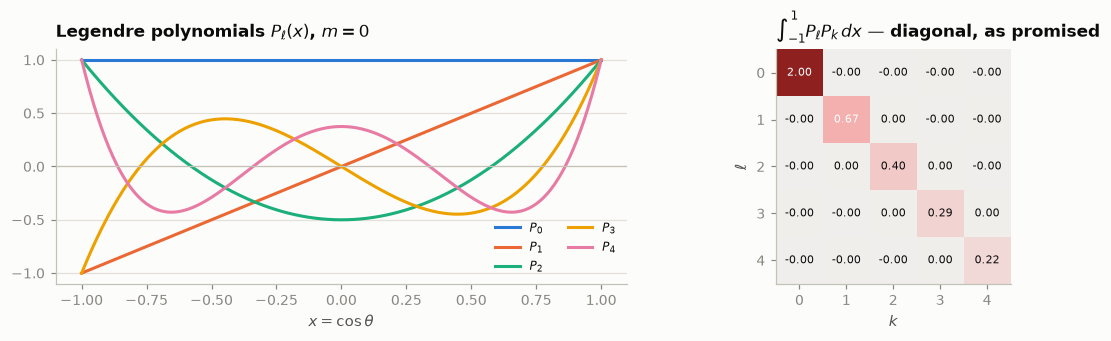

In [2]:
x = np.linspace(-1, 1, 400)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.2))

for l in range(5):
    axes[0].plot(x, sh.assoc_legendre(l, 0, x), color=sp.SERIES[l], label=f"$P_{l}$")
axes[0].set_title("Legendre polynomials $P_\\ell(x)$, $m=0$")
axes[0].set_xlabel("$x = \\cos\\theta$"); axes[0].legend(ncol=2, fontsize=8)
axes[0].axhline(0, color=sp.AXIS, lw=0.8)

# Orthogonality on [-1,1]: <P_l, P_k> = 2/(2l+1) delta_lk
n = 4000
xs = (np.arange(n) + 0.5)/n * 2 - 1
P = np.stack([sh.assoc_legendre(l, 0, xs) for l in range(5)], axis=1)
G = (P.T @ P) * (2.0/n)
axes[1].imshow(G, cmap=sp.CM_DIVERGING, **sp.signed_norm(G))
axes[1].set_title("$\\int_{-1}^{1} P_\\ell P_k\\,dx$ — diagonal, as promised")
axes[1].set_xlabel("$k$"); axes[1].set_ylabel("$\\ell$"); axes[1].grid(False)
for i in range(5):
    for j in range(5):
        axes[1].text(j, i, f"{G[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                     color=sp.INK if abs(G[i,j]) < 0.4 else "white")
fig.tight_layout()

print("diagonal values:", np.round(np.diag(G), 4))
print("predicted 2/(2l+1):", np.round([2/(2*l+1) for l in range(5)], 4))

Note they are orthogonal but **not** orthonormal — the diagonal is $2/(2\ell+1)$,
not 1. That factor is one of the things $K_\ell^m$ has to fix up.

## 3. Associated Legendre polynomials $P_\ell^m(x)$

For $m \neq 0$ we need the *associated* Legendre functions, obtained by
differentiating $m$ times and multiplying by a factor that vanishes at the poles:

$$P_\ell^m(x) = (1-x^2)^{m/2}\,\frac{d^m}{dx^m}P_\ell(x)$$

The $(1-x^2)^{m/2} = \sin^m\theta$ factor is important physically: it forces the
function to zero at the poles. It has to — a function with azimuthal variation
$e^{im\phi}$ cannot be single-valued at a pole where all $\phi$ meet, unless it is
zero there.

In practice nobody differentiates. The recurrence used in `shlib.assoc_legendre` is:

$$\begin{aligned}
P_m^m &= (2m-1)!!\,(1-x^2)^{m/2} &&\text{(the diagonal)}\\
P_{m+1}^m &= x\,(2m+1)\,P_m^m &&\text{(one step up)}\\
P_\ell^m &= \frac{x(2\ell-1)P_{\ell-1}^m - (\ell+m-1)P_{\ell-2}^m}{\ell-m} &&\text{(climb in }\ell)
\end{aligned}$$

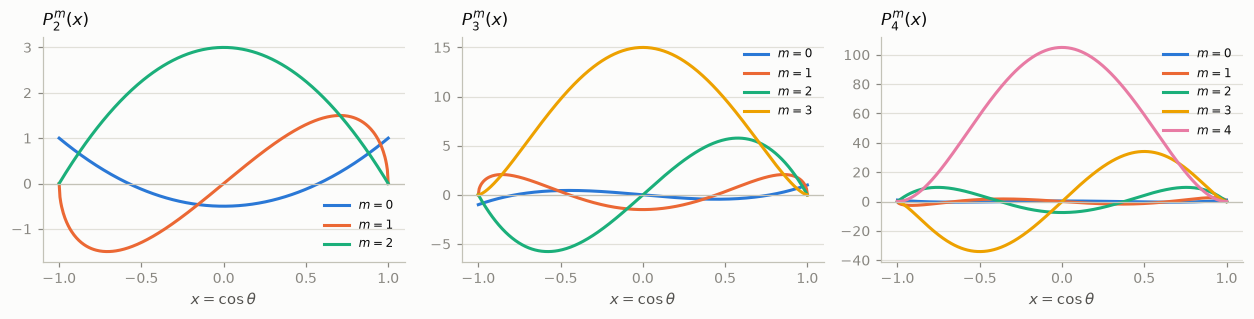

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.0), sharex=True)
for ax, l in zip(axes, [2, 3, 4]):
    for m in range(l+1):
        ax.plot(x, sh.assoc_legendre(l, m, x), color=sp.SERIES[m], label=f"$m={m}$")
    ax.axhline(0, color=sp.AXIS, lw=0.8)
    ax.set_title(f"$P_{{{l}}}^m(x)$"); ax.set_xlabel("$x = \\cos\\theta$")
    ax.legend(fontsize=8)
fig.tight_layout()

Two things to notice, both of which have direct consequences for lighting:

- **Higher $\ell$ wiggles more.** The number of zero crossings grows with $\ell$ —
  that is what "higher frequency" means in the polar direction.
- **Higher $m$ is pinned harder at the poles.** The $\sin^m\theta$ factor flattens
  the function near $x = \pm 1$. High-$m$ terms describe detail near the *equator*.

### The Condon–Shortley phase — a real-world footgun

There is a sign convention that differs between fields. Physics (and SciPy)
includes a factor $(-1)^m$; graphics conventionally drops it.

`shlib` follows the **graphics** convention, so that the standard polynomial table
comes out with clean positive signs — $y_1^1 = +0.488603\,x$ rather than
$-0.488603\,x$.

Watch out: many published graphics snippets write the diagonal step as `(1-2m)`,
which equals $-(2m-1)$ and therefore silently *reintroduces* the phase. If your
band-1 lighting comes out mirrored, this is very likely why.

In [4]:
from scipy.special import lpmv

# scipy's lpmv includes the Condon-Shortley phase; ours does not.
xs = np.linspace(-0.99, 0.99, 7)
print(f"{'(l,m)':>7}{'shlib':>12}{'scipy lpmv':>13}{'ratio':>9}")
print("-" * 42)
for (l, m) in [(1,0), (1,1), (2,1), (2,2), (3,1), (3,3)]:
    a = sh.assoc_legendre(l, m, xs)
    b = lpmv(m, l, xs)
    ratio = np.round(np.mean(b / a), 3)
    print(f"{f'({l},{m})':>7}{a[3]:>12.5f}{b[3]:>13.5f}{ratio:>9.0f}")
print("\nratio is (-1)^m -- exactly the Condon-Shortley phase.")

  (l,m)       shlib   scipy lpmv    ratio
------------------------------------------
  (1,0)     0.00000     -0.00000      nan
  (1,1)     1.00000     -1.00000       -1
  (2,1)     0.00000      0.00000      nan
  (2,2)     3.00000      3.00000        1
  (3,1)    -1.50000      1.50000       -1
  (3,3)    15.00000    -15.00000       -1

ratio is (-1)^m -- exactly the Condon-Shortley phase.


/tmp/ipykernel/3350021317.py:10: RuntimeWarning: invalid value encountered in divide
  ratio = np.round(np.mean(b / a), 3)


## 4. Assembling $Y_\ell^m$

Now put the pieces together. The complex spherical harmonic is

$$Y_\ell^m(\theta,\phi) = K_\ell^m\,P_\ell^m(\cos\theta)\,e^{im\phi},
\qquad K_\ell^m = \sqrt{\frac{2\ell+1}{4\pi}\cdot\frac{(\ell-|m|)!}{(\ell+|m|)!}}$$

The normalisation constant is doing three separate jobs, and it is much less
mysterious when you see them separately:

| factor | fixes |
|---|---|
| $\frac{1}{4\pi}$ | the total solid angle of the sphere |
| $2\ell+1$ | cancels the $2/(2\ell+1)$ we measured on the Legendre diagonal above |
| $\frac{(\ell-m)!}{(\ell+m)!}$ | compensates the growth from differentiating $m$ times |

Together they make $\int_{S^2}|Y_\ell^m|^2 d\omega = 1$.

In [5]:
print(f"{'(l,m)':>8}{'K_l^m':>12}")
print("-" * 21)
for l in range(4):
    for m in range(l+1):
        print(f"{f'({l},{m})':>8}{sh.sh_normalization(l, m):>12.6f}")

   (l,m)       K_l^m
---------------------
   (0,0)    0.282095
   (1,0)    0.488603
   (1,1)    0.345494
   (2,0)    0.630783
   (2,1)    0.257516
   (2,2)    0.128758
   (3,0)    0.746353
   (3,1)    0.215453
   (3,2)    0.068132
   (3,3)    0.027815


max |G - I| = 1.00e+00   (16 harmonics, L0..L3)


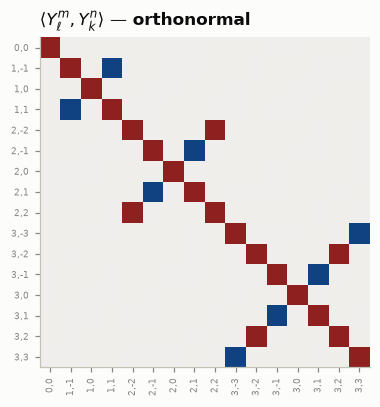

In [6]:
# Confirm the complex harmonics are orthonormal:  <Y_l^m, Y_k^n> = delta.
def complex_Y(l, m, theta, phi):
    k = sh.sh_normalization(l, m)
    return k * sh.assoc_legendre(l, abs(m), np.cos(theta)) * np.exp(1j*abs(m)*phi) \
        * (1 if m >= 0 else (-1)**m)   # Y_l^-m = (-1)^m conj(Y_l^m)

N = 200_000
d = sh.fibonacci_sphere(N)
th, ph = sh.spherical_from_dir(d)

pairs = [(l, m) for l in range(4) for m in range(-l, l+1)]
B = np.stack([complex_Y(l, m, th, ph) for (l, m) in pairs], axis=1)
G = (B.conj().T @ B) * (4*np.pi/N)

print(f"max |G - I| = {np.abs(G - np.eye(len(pairs))).max():.2e}   (16 harmonics, L0..L3)")

fig, ax = plt.subplots(figsize=(4.2, 3.8))
ax.imshow(G.real, cmap=sp.CM_DIVERGING, vmin=-1, vmax=1)
ax.set_title("$\\langle Y_\\ell^m, Y_k^n\\rangle$ — orthonormal")
ax.set_xticks(range(len(pairs)))
ax.set_xticklabels([f"{l},{m}" for l,m in pairs], fontsize=6, rotation=90)
ax.set_yticks(range(len(pairs)))
ax.set_yticklabels([f"{l},{m}" for l,m in pairs], fontsize=6)
ax.grid(False)
fig.tight_layout()

## 5. What they look like

A complex function on a sphere is awkward to draw — it has a magnitude and a phase
at every point. The two standard views:

- **magnitude** $|Y_\ell^m|$ — bands of latitude, independent of $\phi$
- **phase** $\arg Y_\ell^m$ — the $e^{im\phi}$ pinwheel, $m$ full cycles around

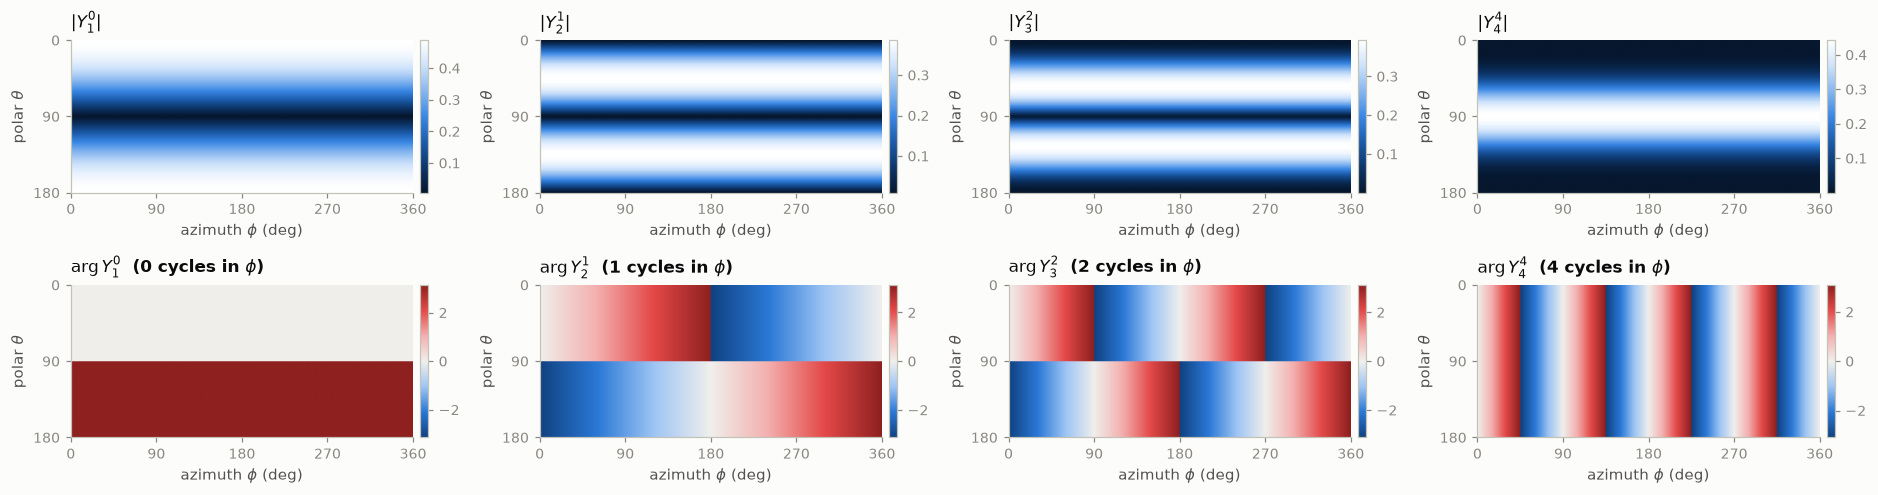

In [7]:
grid = sh.equirect_grid(256, 128)
gt, gp = sh.spherical_from_dir(grid)

show = [(1,0), (2,1), (3,2), (4,4)]
fig, axes = plt.subplots(2, len(show), figsize=(4.3*len(show), 4.6))
for j, (l, m) in enumerate(show):
    Y = complex_Y(l, m, gt, gp)
    sp.show_equirect(np.abs(Y), f"$|Y_{{{l}}}^{{{m}}}|$", ax=axes[0, j])
    sp.show_equirect(np.angle(Y), f"$\\arg Y_{{{l}}}^{{{m}}}$  ({m} cycles in $\\phi$)",
                     ax=axes[1, j], signed=True, cmap=sp.CM_DIVERGING)
fig.tight_layout()

Read the top row: $|Y_\ell^m|$ has $\ell - |m|$ zero-crossings in $\theta$, and is
constant in $\phi$. Read the bottom row: the phase sweeps $m$ times around the
azimuth. Between them, $(\ell, m)$ is exactly "how many wiggles vertically, how
many horizontally".

## 6. The problem with complex harmonics, for us

They are mathematically ideal and practically annoying:

- Our lighting data is **real**. Storing complex coefficients doubles memory for
  information we do not have.
- The redundancy $Y_\ell^{-m} = (-1)^m \overline{Y_\ell^m}$ means half the
  coefficients are determined by the other half — pure waste.
- GPUs have no complex arithmetic. Every evaluation would be hand-expanded anyway.

The fix is to recombine each $\pm m$ pair into two **real** functions, which is
precisely what the graphics basis is. That's notebook 04.

In [8]:
# The redundancy, made concrete.
th0, ph0 = 0.7, 2.1
for l, m in [(1,1), (2,2), (3,1)]:
    a = complex_Y(l, m, th0, ph0)
    b = complex_Y(l, -m, th0, ph0)
    print(f"Y({l},{-m:+d}) = {b:+.6f}   vs   (-1)^{m} * conj(Y({l},{m:+d})) = "
          f"{(-1)**m * np.conj(a):+.6f}")

Y(1,-1) = +0.112365-0.192127j   vs   (-1)^1 * conj(Y(1,+1)) = +0.112365+0.192127j
Y(2,-2) = -0.078594-0.139722j   vs   (-1)^2 * conj(Y(2,+2)) = -0.078594+0.139722j
Y(3,-1) = +0.202325-0.345944j   vs   (-1)^1 * conj(Y(3,+1)) = +0.202325+0.345944j


---

**Next:** [04 — The real SH basis that graphics actually uses](04_real_sh_basis.ipynb)